In [56]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from aquarel import load_theme
from scipy import stats
from pathlib import Path

DF_PATH = Path("../data/covid 19.csv")
df = pd.read_csv(DF_PATH)

In [57]:
# look at the df
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## Cleaning

In [58]:
df.size

2805

In [59]:
# shape
df.shape

(187, 15)

In [60]:
# drop na values
df.dropna(axis=1, inplace=True, how='any')
# set index
df.set_index(df["Country/Region"], inplace=True)
# drop the column
df.drop(columns=["Country/Region"], inplace=True)
# change index name
df.index.name = "Country"

In [61]:
# check data types
df.dtypes

Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                    str
dtype: object

In [62]:
# rename columns
df.rename(columns={"Country/Region": "Country", "Deaths / 100 Cases": "Deaths Per 100 Cases",
                   "Recovered / 100 Cases": "Recovered Per 100 Cases", "Deaths / 100 Recovered": "Deaths Per 100 Recovered"}, inplace=True)

In [63]:
# display options
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)

In [64]:
# create new columns
df["Case Fatality Rate"] = df["Deaths"] / df["Confirmed"]
df["Case Fatality Rate %"] = df["Case Fatality Rate"] * 100

df["Growth Factor"] = 1 + df["1 week % increase"] / 100
# expon. growth rate per unit of time
df["r"] = np.log(df["Growth Factor"]) / 7

# doubling time
df["Doubling Time"] = np.log(2) / df["r"]
df["Doubling Time"] = df["Doubling Time"].replace([np.inf, -np.inf], np.nan)
df.dropna(subset=["Doubling Time"], inplace=True)

In [65]:
# convert WHO Region to category data type
df["WHO Region"] = df["WHO Region"].astype("category")

In [66]:
# cleaning up the Deaths Per 100 Recovered column
df["Deaths Per 100 Recovered"] = df["Deaths Per 100 Recovered"].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Deaths Per 100 Recovered"])

In [67]:
# new dataframe
df.head()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths Per 100 Cases,Recovered Per 100 Cases,Deaths Per 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Case Fatality Rate,Case Fatality Rate %,Growth Factor,r,Doubling Time
Country,,,,,,,,,,,,,,,,,,,
Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean,0.03,3.50,1.02,0.00,236.82
Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe,0.03,2.95,1.17,0.02,30.90
Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa,0.04,4.16,1.18,0.02,29.21
Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe,0.06,5.73,1.03,0.00,189.03
Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa,0.04,4.32,1.27,0.03,20.41


In [68]:
# check whether we have infinite values
for col in df.select_dtypes(include="number").columns:
    print(np.isinf(df[col]).sum())

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


# EXPLORATORY DATA ANALYSIS

## Case Fatality Rate (CFR)

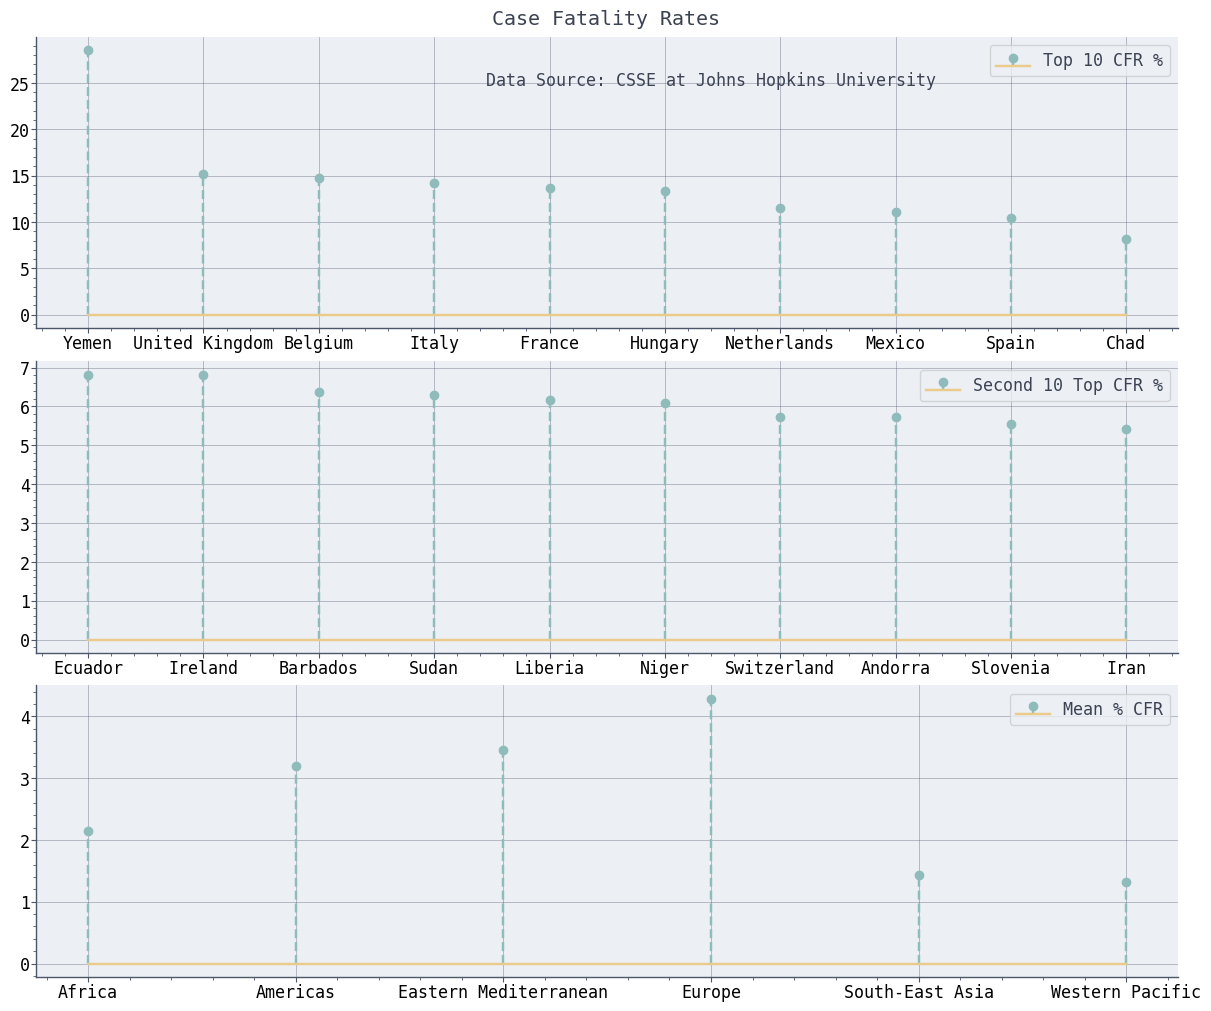

In [69]:
# set up theme and matplotlib params
theme = (
    load_theme("arctic_light").set_grid(width=0.5, alpha=0.5)
    .set_font(family="monospace")
)
theme.apply()

plt.rcParams["font.family"] = "monospace"
plt.rcParams["xtick.labelcolor"] = "black"
plt.rcParams["ytick.labelcolor"] = "black"

# top 20
largest20CFRDf = df["Case Fatality Rate %"].nlargest(20).to_frame()

firstTenLargest = largest20CFRDf.head(10)
secondTenLargest = largest20CFRDf.tail(10)

# mean across WHO regions
meanCFRWhoRegions = df.groupby("WHO Region")["Case Fatality Rate %"].mean()
meanCFRWhoRegionsDf = meanCFRWhoRegions.to_frame()

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), constrained_layout=True)

ax[0].stem(firstTenLargest.index, firstTenLargest.values, linefmt="--", label="Top 10 CFR %")
ax[0].legend(loc="best")

ax[1].stem(secondTenLargest.index, secondTenLargest.values, linefmt="--", label="Second 10 Top CFR %")
ax[1].legend(loc="best")

ax[2].stem(meanCFRWhoRegionsDf.index, meanCFRWhoRegionsDf.values, linefmt="--", label="Mean % CFR")
ax[2].legend(loc="best")

plt.suptitle("Case Fatality Rates")
plt.figtext(x=0.4, y=0.92, s="Data Source: CSSE at Johns Hopkins University")
plt.show()

## Doubling times

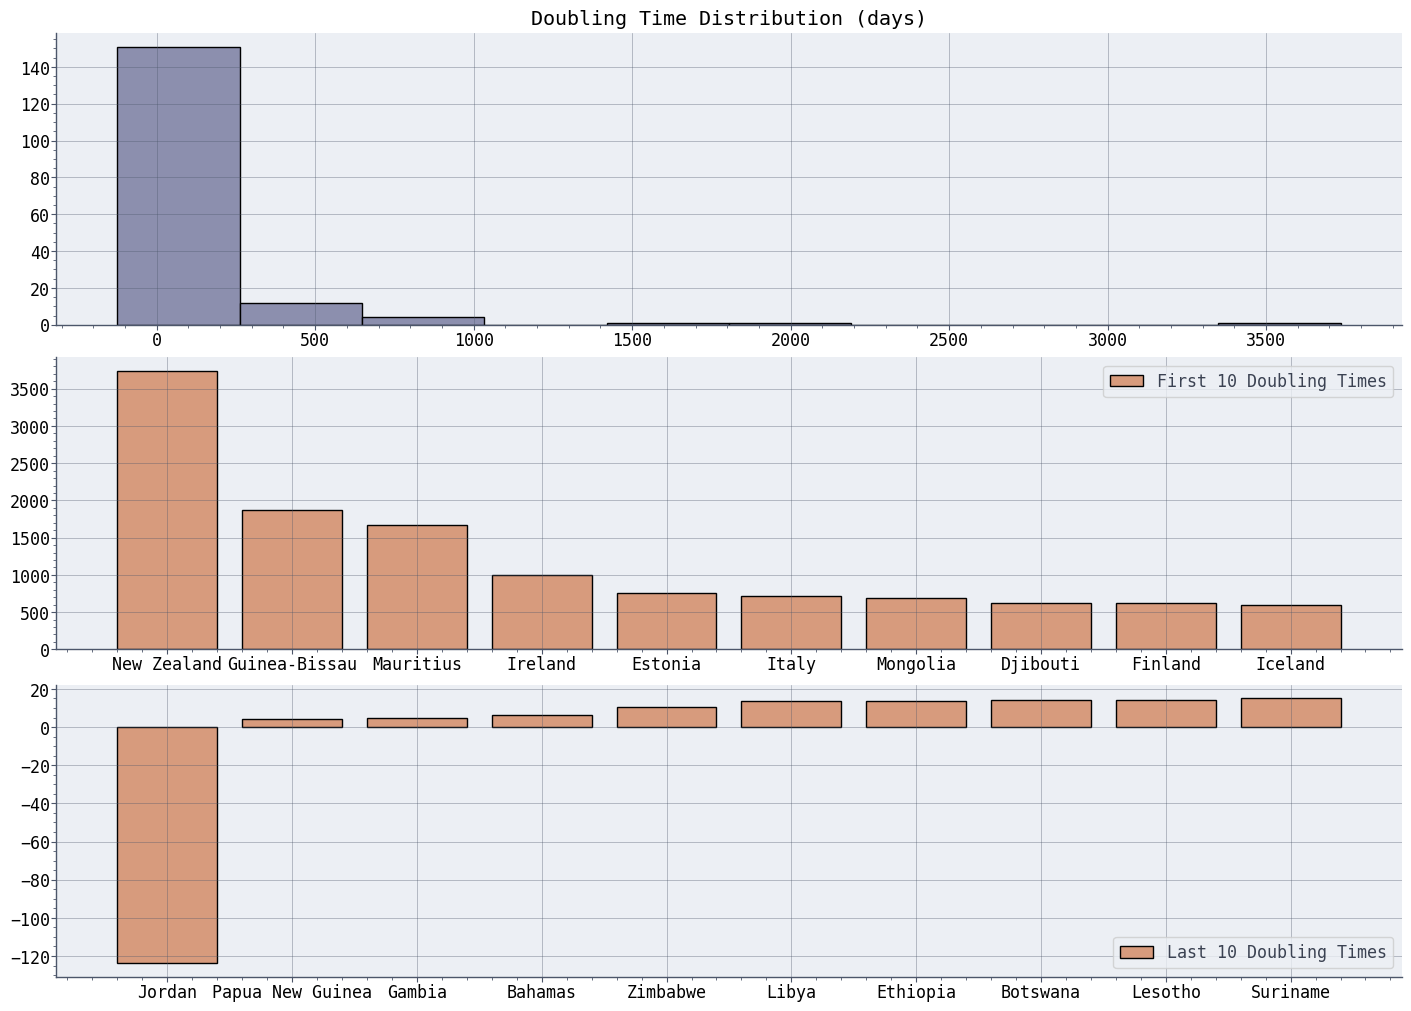

In [70]:
firstTenDoublingTimes = df["Doubling Time"].nlargest(10)
lastTenDoublingTimes = df["Doubling Time"].nsmallest(10)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10),
                         constrained_layout=True)

axes[0].hist(df["Doubling Time"], edgecolor="black", color="#8c8fae")
axes[0].set_title("Doubling Time Distribution (days)", color="black")

axes[1].bar(firstTenDoublingTimes.index, firstTenDoublingTimes.values,
            color="#d79b7d", ec="black", label="First 10 Doubling Times")
axes[1].legend(loc="best")
axes[2].bar(lastTenDoublingTimes.index, lastTenDoublingTimes.values,
            color="#d79b7d", ec="black", label="Last 10 Doubling Times")
axes[2].legend(loc="best")
plt.show()

## Visualizing "Confirmed vs. 1 week % increase" Scatterplot

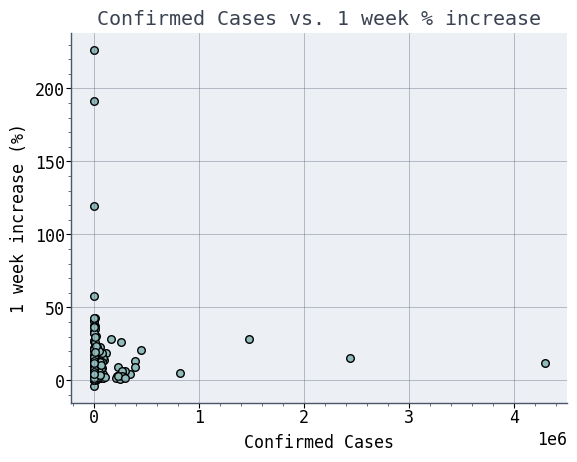

In [71]:
confirmed = df.Confirmed.values
oneWeekIncreases = df['1 week % increase'].values

plt.scatter(confirmed, oneWeekIncreases, s=30, ec="black")
plt.xlabel("Confirmed Cases", color="black")
plt.ylabel("1 week increase (%)", color="black")
plt.tick_params(axis="both", colors="black")
plt.title("Confirmed Cases vs. 1 week % increase")
plt.show()

## Deaths, Recovered and Active Metrics

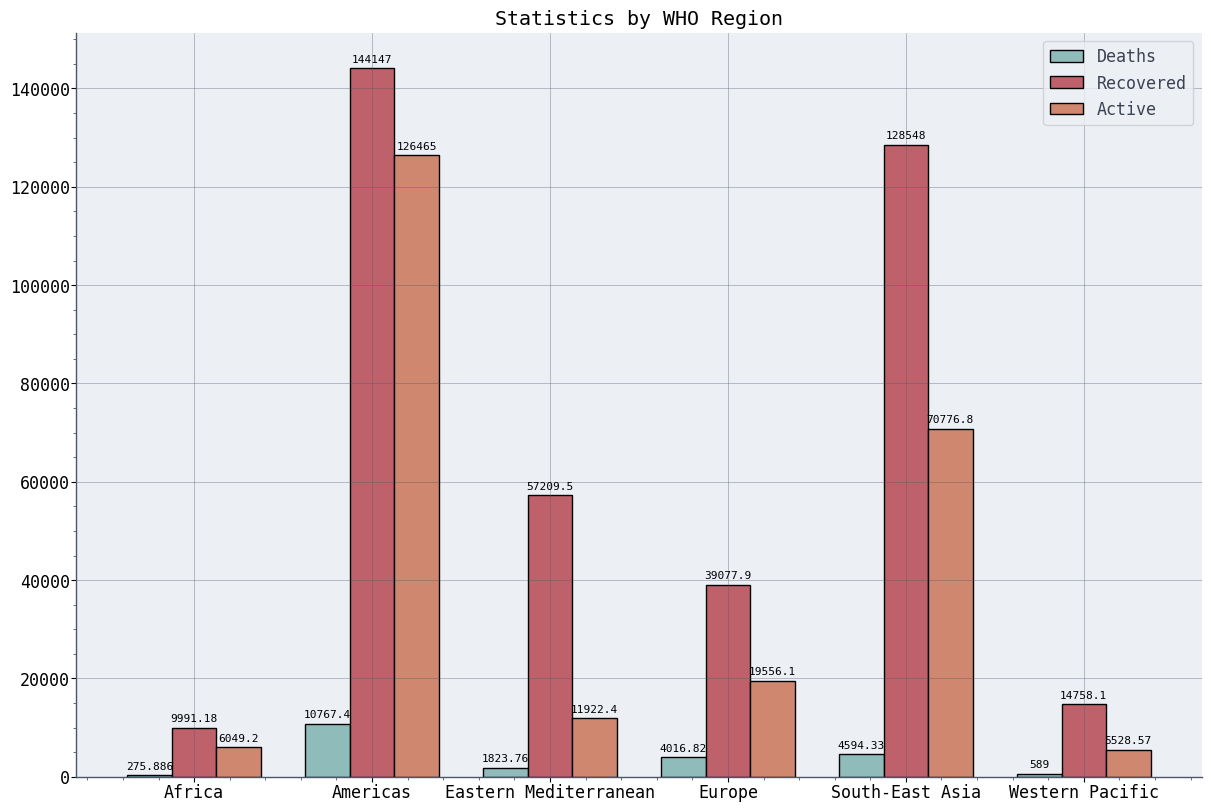

In [72]:
whoRegionMetrics = df.groupby("WHO Region")[["Deaths", "Recovered", "Active"]].agg(["mean"])
whoRegionMetrics.columns = whoRegionMetrics.columns.set_levels(["Mean"], level=1)

columns = whoRegionMetrics.columns.get_level_values(0).unique()
metrics = whoRegionMetrics.columns.get_level_values(1).unique()
rows = whoRegionMetrics.index

meanMetrics = {
    columns[0]: whoRegionMetrics.iloc[:, 0].values,
    columns[1]: whoRegionMetrics.iloc[:, 1].values,
    columns[2]: whoRegionMetrics.iloc[:, 2].values,
}

width = 0.25
x = np.arange(len(rows))
multiplier = 0

fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)

for region, value in meanMetrics.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, value, width, label=region, ec="black")
    ax.bar_label(rects, padding=3, fontsize=8, color="black")
    multiplier += 1

ax.set_xticks(x + width, rows)
ax.tick_params(axis="both", colors="black")
ax.set_title("Statistics by WHO Region", color="black")
ax.legend(loc="best")
plt.show()

### Bubble Chart: Confirmed Cases vs. Deaths Per 100 Cases (%)

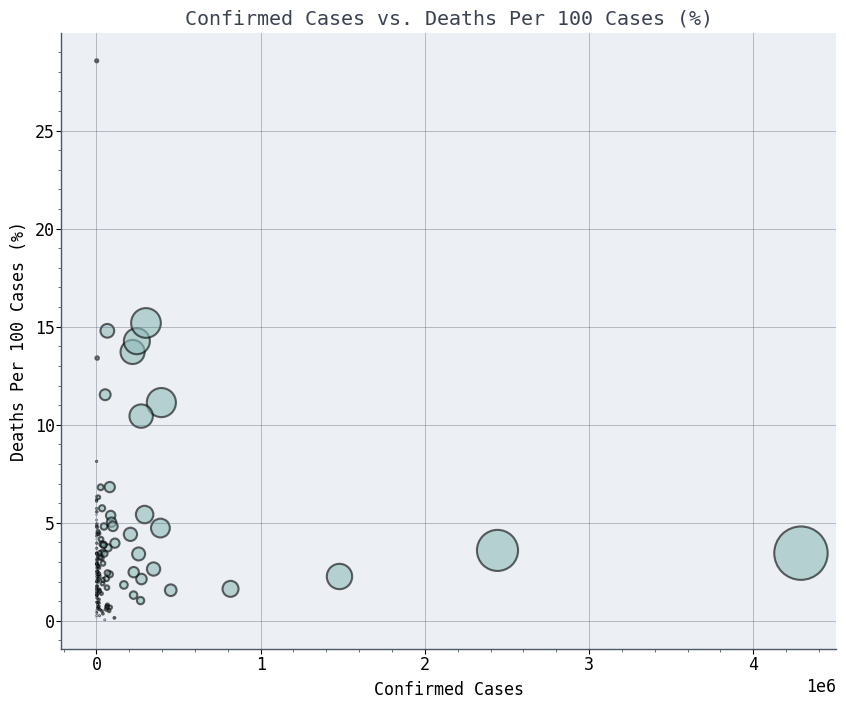

In [73]:
# X-axis: "Confirmed"
# Y-axis: "Deaths Per 100 Cases"
# Bubble size: "Deaths"
x = df["Confirmed"].values
y = df["Deaths Per 100 Cases"].values
actives = df["Deaths"].values / 100 # / 100 to make chart cleaner

plt.figure(figsize=(10, 8))
plt.scatter(x, y, s=actives, edgecolor="black", alpha=0.6, linewidths=1.5)
plt.xlabel("Confirmed Cases", color="black")
plt.ylabel("Deaths Per 100 Cases (%)", color="black")
plt.tick_params(axis="both", color="black")
plt.title("Confirmed Cases vs. Deaths Per 100 Cases (%)")
plt.show()

## Correlation analysis

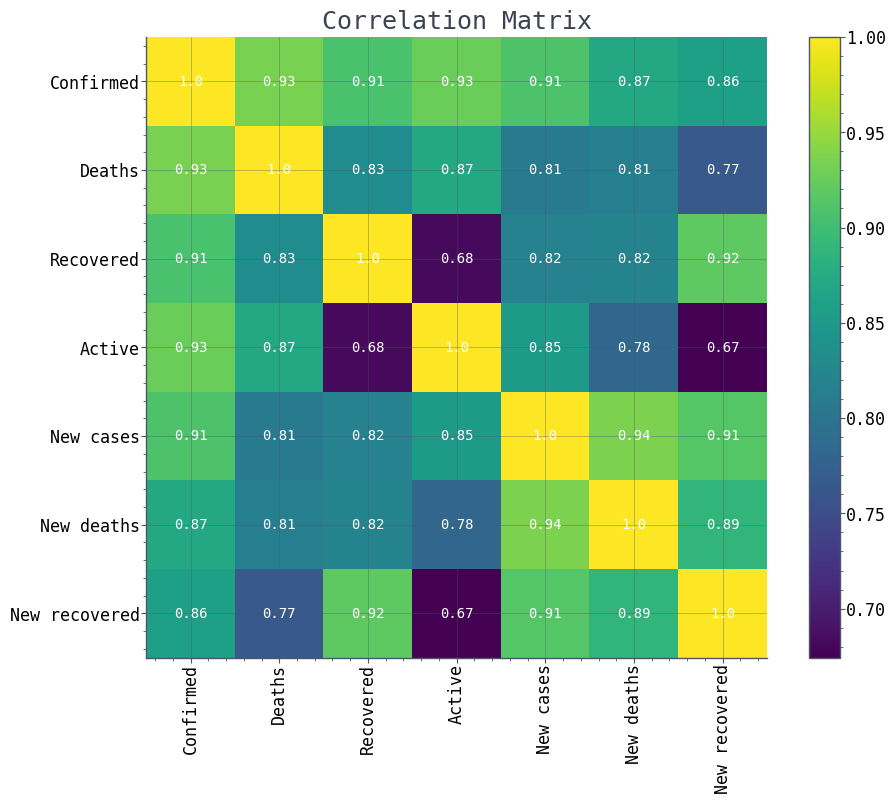

In [74]:
# dataframe only for first 7 columns, otherwise it gets too large
firstSevenColumnsDf = df.iloc[:, :7]
corrCoeff = firstSevenColumnsDf.corr(method="pearson", numeric_only=True)

heatmapLabels = list(corrCoeff.columns)

heatmapValues = [corrCoeff.iloc[0, :].values, corrCoeff.iloc[1, :].values,
                 corrCoeff.iloc[2, :].values, corrCoeff.iloc[3, :].values,
                 corrCoeff.iloc[4, :].values, corrCoeff.iloc[5, :].values,
                 corrCoeff.iloc[6, :].values]

# convert values to np.array() because pandas DataFrame doesn't allow accessing through slicing
heatmapValuesArr = np.array(heatmapValues)

# plotting
plt.subplots(figsize=(10, 8))
heatmap = plt.imshow(heatmapValues)
plt.xticks(np.arange(len(heatmapLabels)), labels=heatmapLabels, rotation=90)
plt.yticks(np.arange(len(heatmapLabels)), labels=heatmapLabels)

for i in range(len(heatmapLabels)):
    for j in range(len(heatmapLabels)):
        text = plt.text(j, i, s=round(heatmapValuesArr[i, j], 2), ha="center", va="center",
                        color="white", fontsize=10)

plt.colorbar(heatmap, location="right")
plt.tight_layout()
plt.title("Correlation Matrix", fontsize=18)
plt.show()


## Outlier Detection using z-score

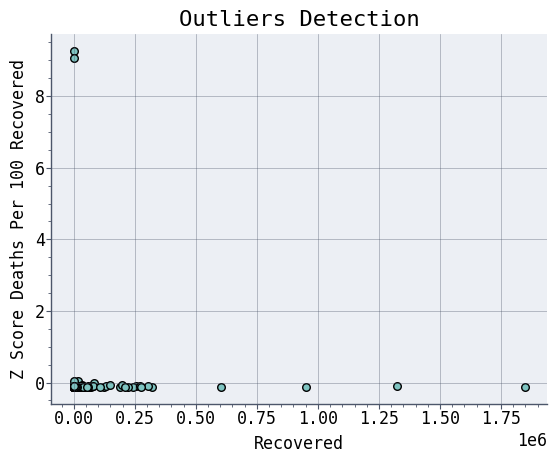

In [75]:
# score
zScoresDeathsPer100Rec = stats.zscore(df["Deaths Per 100 Recovered"].values)

# plotting
plt.scatter(df["Recovered"], zScoresDeathsPer100Rec, ec="black", s=30,
            c="#7ec4c1")
plt.xlabel("Recovered", color="black")
plt.ylabel("Z Score Deaths Per 100 Recovered", color="black")
plt.title("Outliers Detection", fontsize=16, color="black")
plt.show()

# MACHINE LEARNING

### K-means Clustering



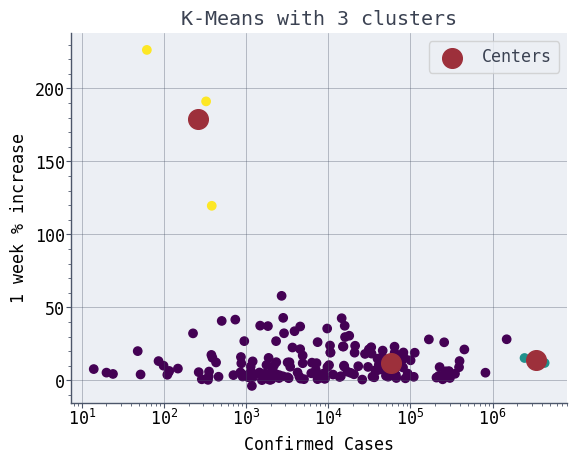

In [76]:
# Using Confirmed and 1 week % increase → standardize → k-means clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sc = StandardScaler()
dfScaled = sc.fit_transform(df[["Confirmed", "1 week % increase"]])

inertias = []
# calculating the best k --> 3: adding more clusters give diminishing returns
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(dfScaled)
    inertias.append(kmeans.inertia_)

"""
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid(alpha=0.6)
plt.show()

"""

# creating the model and converting back the clusters to originals (for plotting)
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
kmeans.fit(dfScaled)
clustersDf = pd.DataFrame(kmeans.cluster_centers_,
                          columns=["Confirmed", "1 week % increase"])
originalClusters = sc.inverse_transform(clustersDf)
originalClustersDf = pd.DataFrame(originalClusters, columns=["Confirmed", "1 week % increase"])

plt.scatter(df["Confirmed"], df["1 week % increase"], marker="o",
            c=kmeans.labels_, cmap="viridis")
plt.scatter(originalClustersDf["Confirmed"], originalClustersDf["1 week % increase"],
            c="#9d303b", s=200, label="Centers")
plt.xlabel("Confirmed Cases", color="black")
plt.ylabel("1 week % increase", color="black")
plt.xscale("log")
plt.legend(loc="best")
plt.title("K-Means with 3 clusters")
plt.show()

### RANDOM FOREST CLASSIFICATION: predicting WHO Region

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV

xRandFor = df[["Confirmed", "Recovered", "Active", "New cases", "New deaths", "New recovered"]]
yRandFor = df['WHO Region']

xTrain, xTest, yTrain, yTest = train_test_split(xRandFor, yRandFor, test_size=0.2, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42,
                                    bootstrap=True, max_features=1/3, oob_score=True)
classifier.fit(xTrain, yTrain)

# looking at the best model with GridSearchCV
paramsGrid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.3],
}

grid = GridSearchCV(estimator=classifier, param_grid=paramsGrid, cv=5, n_jobs=-1)
grid.fit(xTrain, yTrain)

# best params and score
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
0.40476190476190477


In [78]:
# is the dataset balanced in terms of regions?
df["WHO Region"].value_counts(normalize=True, ascending=True)

WHO Region
South-East Asia         0.05
Western Pacific         0.08
Eastern Mediterranean   0.12
Americas                0.18
Africa                  0.26
Europe                  0.30
Name: proportion, dtype: float64

In [79]:
# metrics for Random Forest
yPred = grid.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPred))
print("Conf. Matrix: \n", confusion_matrix(yTest, yPred))
print("Class. Report: \n", classification_report(yTest, yPred))

Accuracy: 0.5
Conf. Matrix: 
 [[ 6  0  0  2  0  0]
 [ 0  0  0  2  0  0]
 [ 1  2  0  3  0  0]
 [ 2  1  0 11  0  0]
 [ 1  1  0  0  0  0]
 [ 2  0  0  0  0  0]]
Class. Report: 
                        precision    recall  f1-score   support

               Africa       0.50      0.75      0.60         8
             Americas       0.00      0.00      0.00         2
Eastern Mediterranean       0.00      0.00      0.00         6
               Europe       0.61      0.79      0.69        14
      South-East Asia       0.00      0.00      0.00         2
      Western Pacific       0.00      0.00      0.00         2

             accuracy                           0.50        34
            macro avg       0.19      0.26      0.21        34
         weighted avg       0.37      0.50      0.42        34



c:\Users\chris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Exploratory Data Analysis Conclusions

1.	The countries with the highest case fatality rates are Yemen (more than 25%), followed by United Kingdom and Belgium. In terms of regions, Europe reaches the highest average case fatality rate, slightly more than 4%. The lowest one is in Westerns Pacific, slightly more than 1%.
2.	According to my analysis, New Zealand would double in slightly more than 3500 days if the current exponential growth rate remained constant. Guinea-Bissau comes second, at just less than 2000 days.
3.	Countries with the most confirmed cases don’t show, according to the data, a higher 1-week % increase. Less confirmed cases have higher 1-week % increases, with a few ones even reaching more than 100%. The same happens when plotting Confirmed Cases and Deaths Per 100 Cases (%).
4.	In absolute terms, Americas has the highest Deaths, Recovered people and Active cases, followed by South-East Asia. Regions containing highly populated countries tend to show larger absolute counts of deaths, recoveries and active cases.
5.	More Recovered people don’t necessarily indicate lower Deaths Per 100 Recovered. Some countries have high Recovered numbers (100k) but still have a Deaths Per 100 Recovered z-score close to 0. The same with countries with 25k Recovered people.

## Machine Learning Conclusions

I trained two models:
1.	K-Means: the elbow method suggested that 3 clusters may be a reasonable choice:
-	The first one includes almost all data: it groups together confirmed cases that have a low-medium weekly % increase.
-	The second one is found at the bottom right of the chart and groups some outliers with extreme confirmed cases but relatively low weekly % increase.
-	The third one categorizes a few points that have relatively low confirmed cases (from 10 to 1000) but very high 1-week % increase (more than 100%). This suggests a few datapoints are outliers but they make up just a tiny fraction of the dataset.
2.	Random Forest Classification: I used a few features to predict WHO Region. 
-	The model performed decently as suggested by the accuracy score of 0.5. By itself, it doesn’t mean a lot as the dataset is slightly imbalanced (Europe accounting for 30%, Africa 26%, Americas 18%, Eastern Mediterranean 12%, Western Pacific 8% and South-East Asia 5%), therefore we need further confirmation from the other metrics.
-	Random Forest had varying performance in terms of precision metric: when it predicts Africa and Europe it is right 50% and 61% of the time, respectively. But in all other cases it is never right, as evidenced by the 0% scores. 
-	The same is true for recall score where the model predicted 75% of true positives for Africa and 79% for Europe. For all the other regions, it scored 0%. This suggests that it doesn’t work well with all the other regions, except for Africa and Europe, which make up 56% of the data.
-	The f1 score, which combines precision and recall, confirms the last sentence further.